In [6]:
import pandas as pd
from pathlib import Path

EXTENDED_EXPERIMENTS_CSV_PATH = Path("experiments/experiments_large.csv")

experiments_dataframe = pd.read_csv(EXTENDED_EXPERIMENTS_CSV_PATH)

experiments_dataframe["date"] = pd.to_datetime(experiments_dataframe["date"])

boolean_column_names = [
    "architecture_use_residual_connections",
    "architecture_use_attention_gates",
    "architecture_use_h_swish",
]
for boolean_column_name in boolean_column_names:
    if boolean_column_name in experiments_dataframe.columns:
        experiments_dataframe[boolean_column_name] = experiments_dataframe[boolean_column_name].astype("boolean")

In [7]:
DISPLAY_COLUMNS = [
    "run_id", "date", "dataset", "parameters",
    "mean_val_dice", "std_val_dice", "architecture_use_attention_gates", "architecture_encoder_channels"
]

dataset_filter = experiments_dataframe["dataset"] == "EMSegmentation"
depthwise_separable_filter = experiments_dataframe["architecture_use_depthwise_separable_convolutions"] == True
encoder_channels_filter = experiments_dataframe["architecture_encoder_channels"] == '[8, 16, 32]'
architecture_normalization_filter = experiments_dataframe["architecture_normalization"] == 'batch_norm'
hypothesis_filter = (experiments_dataframe["hypothesis"] == 'Attention gates improves dice.') | (experiments_dataframe["hypothesis"] == 'Add vs Concat in skip connections.')
# architecture_use_residual_connections_filter = experiments_dataframe["architecture_use_residual_connections"] == False

emsegmentation_experiments_dataframe = experiments_dataframe.loc[
    dataset_filter & hypothesis_filter,
    DISPLAY_COLUMNS
].sort_values("parameters", ascending=False)

emsegmentation_experiments_dataframe

,run_id,date,dataset,parameters,mean_val_dice,std_val_dice,architecture_use_attention_gates,architecture_encoder_channels
62,2026_06_25_15_44_18,2026-06-25,EMSegmentation,44977,0.9171,0.0069,True,"[8, 16, 32, 64]"
60,2026_06_25_15_03_15,2026-06-25,EMSegmentation,40177,0.9262,0.0025,False,"[8, 16, 32, 64]"
63,2026_06_25_15_57_55,2026-06-25,EMSegmentation,13569,0.8674,0.0121,True,"[8, 16, 32]"
61,2026_06_25_15_18_14,2026-06-25,EMSegmentation,11345,0.8506,0.0177,False,"[8, 16, 32]"
64,2026_06_25_18_15_00,2026-06-25,EMSegmentation,4257,0.7073,0.0248,True,"[8, 16]"
65,2026_06_26_07_56_58,2026-06-26,EMSegmentation,3329,0.7215,0.0175,False,"[8, 16]"


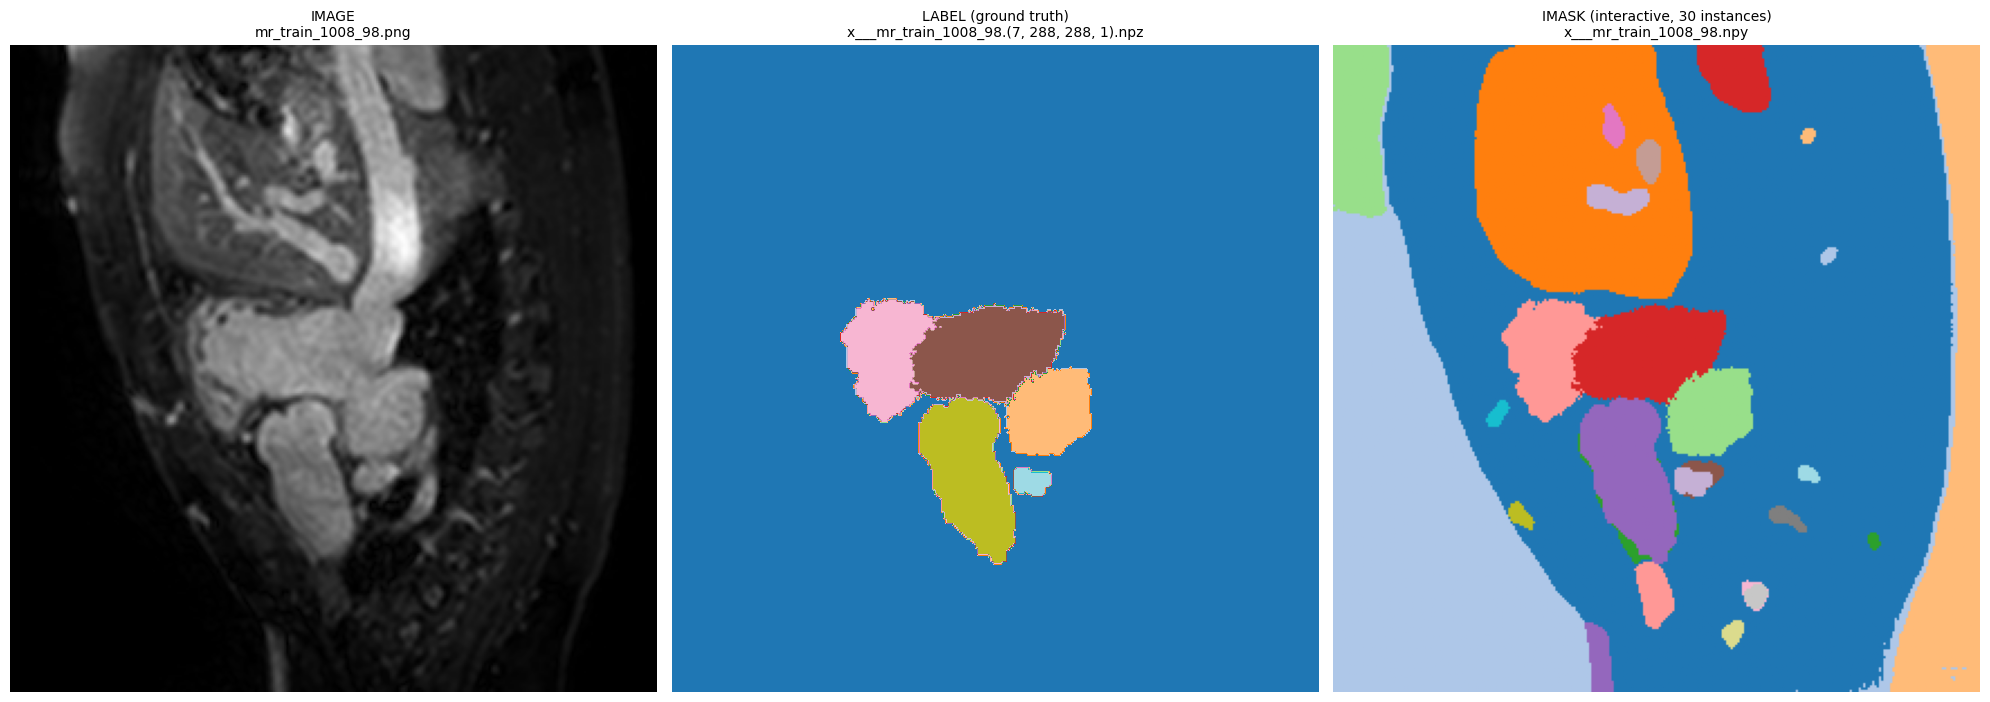

In [8]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse
from PIL import Image


def find_file_by_case_prefix(folder, case_identifier):
    matching_filepaths = sorted(folder.glob(f"{case_identifier}.*"))
    if not matching_filepaths:
        raise FileNotFoundError(f'No file starting with "{case_identifier}." found in {folder}')
    if len(matching_filepaths) > 1:
        raise ValueError(f'Multiple files match "{case_identifier}." in {folder}: {matching_filepaths}')
    return matching_filepaths[0]


def find_image_file(image_folder, case_identifier):
    if "___" in case_identifier:
        path_segment, bare_case_identifier = case_identifier.split("___", maxsplit=1)
        candidate_folder = image_folder / path_segment
        if candidate_folder.is_dir():
            return find_file_by_case_prefix(candidate_folder, bare_case_identifier)
    return find_file_by_case_prefix(image_folder, case_identifier)


def squeeze_trailing_singleton_dimension(array):
    while array.ndim > 2 and array.shape[-1] == 1:
        array = array.squeeze(axis=-1)
    return array


def load_image_panel(dataset_directory, case_identifier):
    image_filepath = find_image_file(dataset_directory / "image", case_identifier)
    return np.array(Image.open(image_filepath)), image_filepath.name


def load_label_panel(dataset_directory, case_identifier):
    label_filepath = find_file_by_case_prefix(dataset_directory / "label", case_identifier)

    shape_string = label_filepath.name.split(".")[-2]
    one_hot_shape = ast.literal_eval(shape_string)

    sparse_matrix = sparse.load_npz(label_filepath)
    one_hot_array = sparse_matrix.toarray().reshape(one_hot_shape)

    number_of_label_channels = one_hot_array.shape[0]
    squeezed_array = one_hot_array.squeeze(axis=-1) if one_hot_array.shape[-1] == 1 else one_hot_array

    if number_of_label_channels == 1:
        class_index_map = squeezed_array[0]
        color_map_name = "gray"
        color_scale_max = 1
    else:
        class_index_map = squeezed_array.argmax(axis=0)
        color_map_name = "tab20"
        color_scale_max = number_of_label_channels - 1

    return class_index_map, color_map_name, color_scale_max, label_filepath.name


def load_imask_panel(dataset_directory, case_identifier):
    imask_filepath = find_file_by_case_prefix(dataset_directory / "imask", case_identifier)

    instance_id_array = squeeze_trailing_singleton_dimension(np.load(imask_filepath))
    positive_instance_ids = np.unique(instance_id_array[instance_id_array != -1])

    colormap = plt.colormaps.get_cmap("tab20")
    colored_instance_map = np.zeros((*instance_id_array.shape, 3), dtype=np.float32)
    for color_index, instance_id in enumerate(positive_instance_ids):
        colored_instance_map[instance_id_array == instance_id] = colormap(color_index % 20)[:3]

    return colored_instance_map, len(positive_instance_ids), imask_filepath.name


def visualize_image_label_imask_triplet(dataset_folder_name, case_identifier):
    dataset_directory = Path("data") / dataset_folder_name

    real_image_array, image_filename = load_image_panel(dataset_directory, case_identifier)
    label_class_index_map, label_color_map_name, label_color_scale_max, label_filename = load_label_panel(dataset_directory, case_identifier)
    colored_instance_map, instance_count, imask_filename = load_imask_panel(dataset_directory, case_identifier)

    figure, (image_axes, label_axes, imask_axes) = plt.subplots(1, 3, figsize=(20, 7))

    image_axes.imshow(real_image_array)
    image_axes.set_title(f"IMAGE\n{image_filename}", fontsize=10)
    image_axes.axis("off")

    label_axes.imshow(label_class_index_map, cmap=label_color_map_name, vmin=0, vmax=label_color_scale_max)
    label_axes.set_title(f"LABEL (ground truth)\n{label_filename}", fontsize=10)
    label_axes.axis("off")

    imask_axes.imshow(colored_instance_map)
    imask_axes.set_title(f"IMASK (interactive, {instance_count} instances)\n{imask_filename}", fontsize=10)
    imask_axes.axis("off")

    plt.tight_layout()
    plt.show()


visualize_image_label_imask_triplet(dataset_folder_name="MmWhsMr", case_identifier="x___mr_train_1008_98")

# Baseline

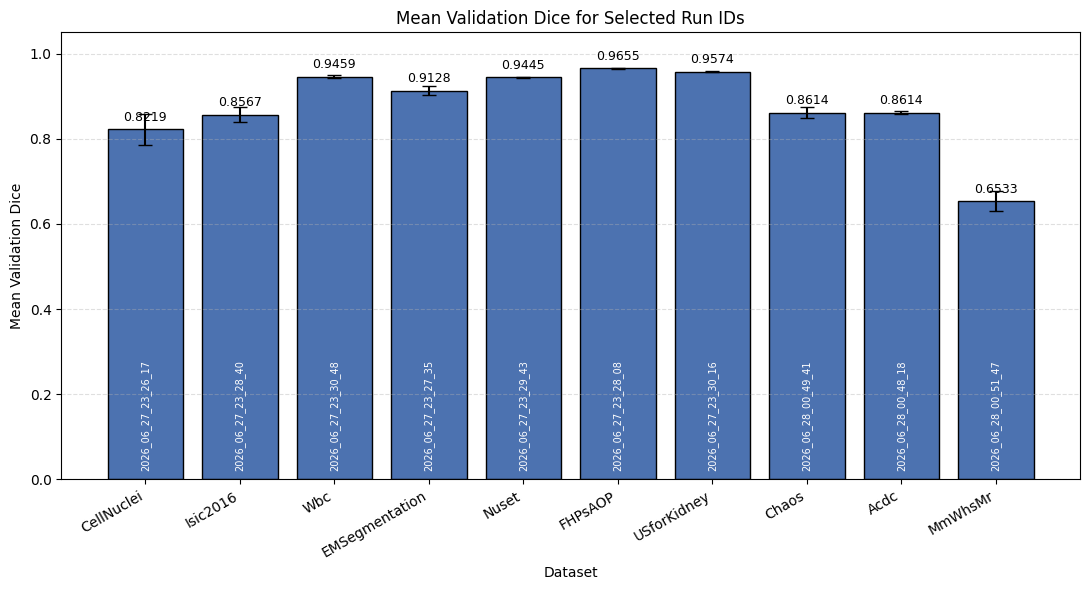

In [9]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt


EXPERIMENTS_CSV_PATH = Path("experiments/experiments.csv")

RUN_IDS_TO_DISPLAY = [
    "2026_06_27_23_26_17",
    "2026_06_27_23_28_40",
    "2026_06_27_23_30_48",
    "2026_06_27_23_27_35",
    "2026_06_27_23_29_43",
    "2026_06_27_23_28_08",
    "2026_06_27_23_30_16",
    "2026_06_28_00_49_41",
    "2026_06_28_00_48_18",
    "2026_06_28_00_51_47"
]


def read_experiment_rows_by_run_id(csv_path, run_ids_to_keep):
    experiment_by_run_id = {}
    with open(csv_path, "r", newline="") as csv_file:
        csv_reader = csv.DictReader(csv_file)
        for row in csv_reader:
            run_id = row["run_id"].strip()
            if run_id not in run_ids_to_keep:
                continue
            experiment_by_run_id[run_id] = {
                "dataset": row["dataset"].strip(),
                "mean_val_dice": float(row["mean_val_dice"]),
                "std_val_dice": float(row["std_val_dice"]),
            }
    return experiment_by_run_id


def plot_mean_dice_bar_chart_with_run_ids(experiment_by_run_id, run_id_display_order):
    run_ids = [run_id for run_id in run_id_display_order if run_id in experiment_by_run_id]
    dataset_names = [experiment_by_run_id[run_id]["dataset"] for run_id in run_ids]
    mean_dice_values = [experiment_by_run_id[run_id]["mean_val_dice"] for run_id in run_ids]
    std_dice_values = [experiment_by_run_id[run_id]["std_val_dice"] for run_id in run_ids]

    figure, axes = plt.subplots(figsize=(11, 6))
    bar_positions = range(len(run_ids))

    axes.bar(
        bar_positions,
        mean_dice_values,
        yerr=std_dice_values,
        capsize=5,
        color="#4C72B0",
        edgecolor="black",
    )

    for position, mean_dice_value, run_id in zip(bar_positions, mean_dice_values, run_ids):
        axes.text(position, mean_dice_value + 0.02, f"{mean_dice_value:.4f}", ha="center", fontsize=9)
        axes.text(position, 0.02, run_id, ha="center", va="bottom", fontsize=7, rotation=90, color="white")

    axes.set_xticks(list(bar_positions))
    axes.set_xticklabels(dataset_names, rotation=30, ha="right")
    axes.set_xlabel("Dataset")
    axes.set_ylabel("Mean Validation Dice")
    axes.set_title("Mean Validation Dice for Selected Run IDs")
    axes.set_ylim(0, 1.05)
    axes.grid(axis="y", linestyle="--", alpha=0.4)

    figure.tight_layout()
    plt.show()


experiment_by_run_id = read_experiment_rows_by_run_id(EXPERIMENTS_CSV_PATH, RUN_IDS_TO_DISPLAY)
plot_mean_dice_bar_chart_with_run_ids(experiment_by_run_id, RUN_IDS_TO_DISPLAY)

# Skip Connection Add vs Baseline

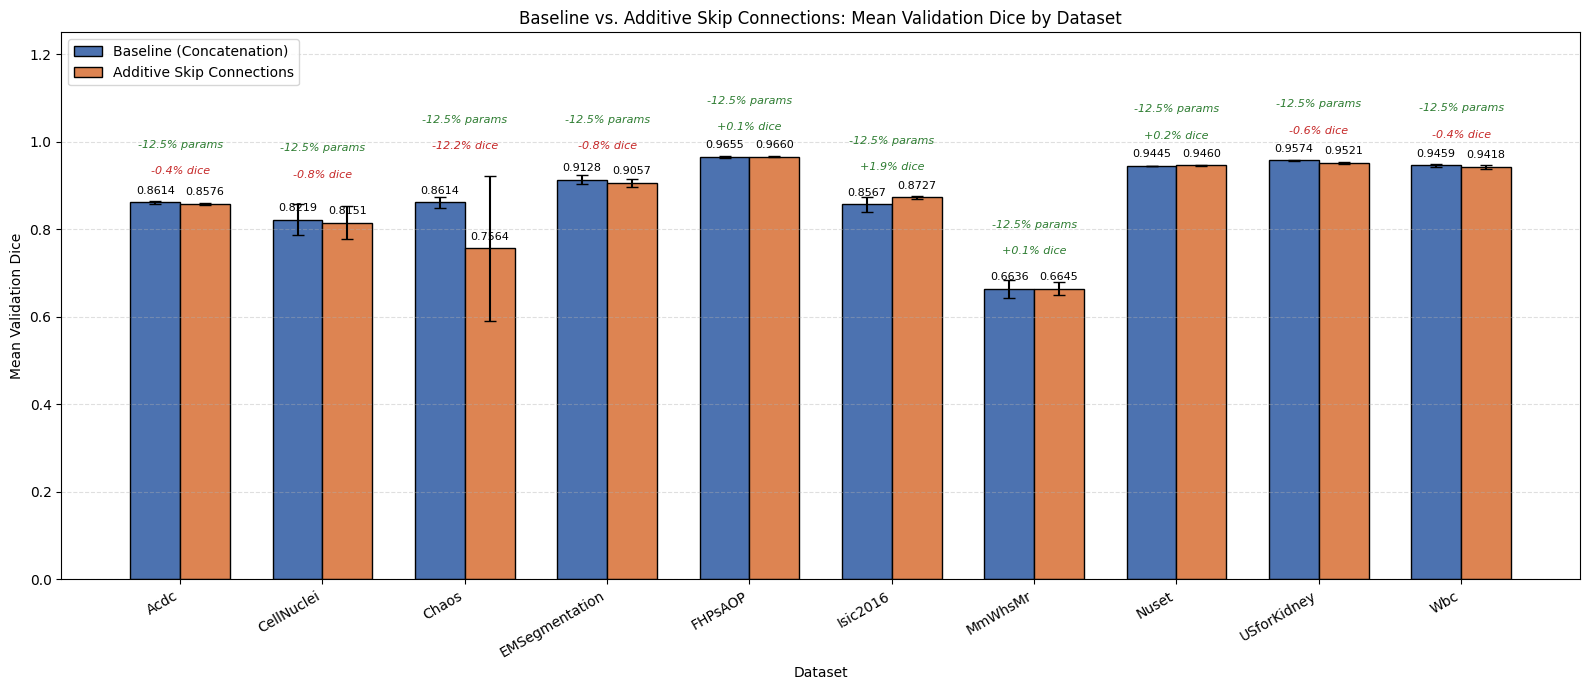

In [3]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt


EXPERIMENTS_CSV_PATH = Path("experiments/experiments.csv")
DATASETS_TO_DISPLAY = [
    "Acdc", "CellNuclei", "Chaos", "EMSegmentation", "FHPsAOP", "Isic2016", "MmWhsMr",
    "Nuset", "USforKidney", "Wbc"
]
BASELINE_HYPOTHESIS_TEXT = "No hypothesis -  Baseline."
ADDITIVE_SKIP_CONNECTION_HYPOTHESIS_TEXT = "Using addition instead of concatenation in skip connections reduces parameters without losing much in dice."


def read_all_experiment_rows_sorted_by_run_id(csv_path, dataset_names_to_keep):
    experiment_rows = []
    with open(csv_path, "r", newline="") as csv_file:
        csv_reader = csv.DictReader(csv_file)
        for row in csv_reader:
            dataset_name = row["dataset"].strip()
            if dataset_name not in dataset_names_to_keep:
                continue
            experiment_rows.append({
                "run_id": row["run_id"].strip(),
                "dataset": dataset_name,
                "hypothesis": row["hypothesis"],
                "parameters": int(row["parameters"]),
                "mean_val_dice": float(row["mean_val_dice"]),
                "std_val_dice": float(row["std_val_dice"]),
            })

    experiment_rows.sort(key=lambda experiment_row: experiment_row["run_id"])
    return experiment_rows


def keep_latest_run_per_dataset_and_hypothesis(experiment_rows_sorted_by_run_id):
    latest_experiment_by_dataset_and_hypothesis = {}
    for experiment_row in experiment_rows_sorted_by_run_id:
        dataset_and_hypothesis_key = (experiment_row["dataset"], experiment_row["hypothesis"])
        latest_experiment_by_dataset_and_hypothesis[dataset_and_hypothesis_key] = experiment_row
    return latest_experiment_by_dataset_and_hypothesis


def select_baseline_and_additive_skip_connection_experiments(
    latest_experiment_by_dataset_and_hypothesis, dataset_display_order
):
    baseline_experiment_by_dataset = {}
    additive_skip_connection_experiment_by_dataset = {}

    for dataset_name in dataset_display_order:
        baseline_key = (dataset_name, BASELINE_HYPOTHESIS_TEXT)
        additive_skip_connection_key = (dataset_name, ADDITIVE_SKIP_CONNECTION_HYPOTHESIS_TEXT)

        if baseline_key in latest_experiment_by_dataset_and_hypothesis:
            baseline_experiment_by_dataset[dataset_name] = latest_experiment_by_dataset_and_hypothesis[baseline_key]
        if additive_skip_connection_key in latest_experiment_by_dataset_and_hypothesis:
            additive_skip_connection_experiment_by_dataset[dataset_name] = (
                latest_experiment_by_dataset_and_hypothesis[additive_skip_connection_key]
            )

    dataset_names_with_both_experiments = [
        dataset_name
        for dataset_name in dataset_display_order
        if dataset_name in baseline_experiment_by_dataset
        and dataset_name in additive_skip_connection_experiment_by_dataset
    ]

    return (
        dataset_names_with_both_experiments,
        baseline_experiment_by_dataset,
        additive_skip_connection_experiment_by_dataset,
    )


def compute_parameter_percentage_change_by_dataset(
    dataset_names, baseline_experiment_by_dataset, additive_skip_connection_experiment_by_dataset
):
    parameter_percentage_change_by_dataset = {}
    for dataset_name in dataset_names:
        baseline_parameter_count = baseline_experiment_by_dataset[dataset_name]["parameters"]
        additive_skip_connection_parameter_count = additive_skip_connection_experiment_by_dataset[dataset_name]["parameters"]
        parameter_percentage_change = (
            (additive_skip_connection_parameter_count - baseline_parameter_count) / baseline_parameter_count
        ) * 100
        parameter_percentage_change_by_dataset[dataset_name] = parameter_percentage_change
    return parameter_percentage_change_by_dataset


def compute_dice_percentage_change_by_dataset(
    dataset_names, baseline_experiment_by_dataset, additive_skip_connection_experiment_by_dataset
):
    dice_percentage_change_by_dataset = {}
    for dataset_name in dataset_names:
        baseline_mean_dice = baseline_experiment_by_dataset[dataset_name]["mean_val_dice"]
        additive_skip_connection_mean_dice = additive_skip_connection_experiment_by_dataset[dataset_name]["mean_val_dice"]
        dice_percentage_change = (
            (additive_skip_connection_mean_dice - baseline_mean_dice) / baseline_mean_dice
        ) * 100
        dice_percentage_change_by_dataset[dataset_name] = dice_percentage_change
    return dice_percentage_change_by_dataset


def choose_color_for_dice_percentage_change(dice_percentage_change):
    if dice_percentage_change >= 0:
        return "#2E7D32"
    return "#C62828"


def choose_color_for_parameter_percentage_change(parameter_percentage_change):
    if parameter_percentage_change <= 0:
        return "#2E7D32"
    return "#C62828"


def plot_baseline_versus_additive_skip_connection_dice_bar_chart(
    dataset_names,
    baseline_experiment_by_dataset,
    additive_skip_connection_experiment_by_dataset,
    parameter_percentage_change_by_dataset,
    dice_percentage_change_by_dataset,
):
    baseline_mean_dice_values = [
        baseline_experiment_by_dataset[dataset_name]["mean_val_dice"] for dataset_name in dataset_names
    ]
    baseline_std_dice_values = [
        baseline_experiment_by_dataset[dataset_name]["std_val_dice"] for dataset_name in dataset_names
    ]
    additive_skip_connection_mean_dice_values = [
        additive_skip_connection_experiment_by_dataset[dataset_name]["mean_val_dice"]
        for dataset_name in dataset_names
    ]
    additive_skip_connection_std_dice_values = [
        additive_skip_connection_experiment_by_dataset[dataset_name]["std_val_dice"]
        for dataset_name in dataset_names
    ]

    figure, axes = plt.subplots(figsize=(16, 7))
    bar_positions = range(len(dataset_names))
    bar_width = 0.35
    baseline_bar_positions = [position - bar_width / 2 for position in bar_positions]
    additive_skip_connection_bar_positions = [position + bar_width / 2 for position in bar_positions]

    axes.bar(
        baseline_bar_positions,
        baseline_mean_dice_values,
        width=bar_width,
        yerr=baseline_std_dice_values,
        capsize=4,
        color="#4C72B0",
        edgecolor="black",
        label="Baseline (Concatenation)",
    )
    axes.bar(
        additive_skip_connection_bar_positions,
        additive_skip_connection_mean_dice_values,
        width=bar_width,
        yerr=additive_skip_connection_std_dice_values,
        capsize=4,
        color="#DD8452",
        edgecolor="black",
        label="Additive Skip Connections",
    )

    for position, mean_dice_value in zip(baseline_bar_positions, baseline_mean_dice_values):
        axes.text(position, mean_dice_value + 0.02, f"{mean_dice_value:.4f}", ha="center", fontsize=8)
    for position, mean_dice_value in zip(additive_skip_connection_bar_positions, additive_skip_connection_mean_dice_values):
        axes.text(position, mean_dice_value + 0.02, f"{mean_dice_value:.4f}", ha="center", fontsize=8)

    for dataset_position, dataset_name in zip(bar_positions, dataset_names):
        parameter_percentage_change = parameter_percentage_change_by_dataset[dataset_name]
        dice_percentage_change = dice_percentage_change_by_dataset[dataset_name]
        parameter_change_label = f"{parameter_percentage_change:+.1f}% params"
        dice_change_label = f"{dice_percentage_change:+.1f}% dice"
        tallest_bar_height_for_dataset = max(
            baseline_experiment_by_dataset[dataset_name]["mean_val_dice"]
            + baseline_experiment_by_dataset[dataset_name]["std_val_dice"],
            additive_skip_connection_experiment_by_dataset[dataset_name]["mean_val_dice"]
            + additive_skip_connection_experiment_by_dataset[dataset_name]["std_val_dice"],
        )
        parameter_change_color = choose_color_for_parameter_percentage_change(parameter_percentage_change)
        dice_change_color = choose_color_for_dice_percentage_change(dice_percentage_change)
        axes.text(
            dataset_position,
            tallest_bar_height_for_dataset + 0.12,
            parameter_change_label,
            ha="center",
            fontsize=8,
            color=parameter_change_color,
            style="italic",
        )
        axes.text(
            dataset_position,
            tallest_bar_height_for_dataset + 0.06,
            dice_change_label,
            ha="center",
            fontsize=8,
            color=dice_change_color,
            style="italic",
        )

    axes.set_xticks(list(bar_positions))
    axes.set_xticklabels(dataset_names, rotation=30, ha="right")
    axes.set_xlabel("Dataset")
    axes.set_ylabel("Mean Validation Dice")
    axes.set_title("Baseline vs. Additive Skip Connections: Mean Validation Dice by Dataset")
    axes.set_ylim(0, 1.25)
    axes.grid(axis="y", linestyle="--", alpha=0.4)
    axes.legend(loc="upper left")

    figure.tight_layout()
    plt.show()


experiment_rows_sorted_by_run_id = read_all_experiment_rows_sorted_by_run_id(
    EXPERIMENTS_CSV_PATH, DATASETS_TO_DISPLAY
)
latest_experiment_by_dataset_and_hypothesis = keep_latest_run_per_dataset_and_hypothesis(
    experiment_rows_sorted_by_run_id
)
(
    dataset_names_with_both_experiments,
    baseline_experiment_by_dataset,
    additive_skip_connection_experiment_by_dataset,
) = select_baseline_and_additive_skip_connection_experiments(
    latest_experiment_by_dataset_and_hypothesis, DATASETS_TO_DISPLAY
)
parameter_percentage_change_by_dataset = compute_parameter_percentage_change_by_dataset(
    dataset_names_with_both_experiments,
    baseline_experiment_by_dataset,
    additive_skip_connection_experiment_by_dataset,
)
dice_percentage_change_by_dataset = compute_dice_percentage_change_by_dataset(
    dataset_names_with_both_experiments,
    baseline_experiment_by_dataset,
    additive_skip_connection_experiment_by_dataset,
)
plot_baseline_versus_additive_skip_connection_dice_bar_chart(
    dataset_names_with_both_experiments,
    baseline_experiment_by_dataset,
    additive_skip_connection_experiment_by_dataset,
    parameter_percentage_change_by_dataset,
    dice_percentage_change_by_dataset,
)